# Plotting velocity vectors, pathlines, streamlines, and streaklines

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint


## Creation of a grid of points and showing velocity vectors

We are interested in a two-dimensional domain and are given some $u(x, y)$, $v(x, y)$


In all of these please see the documentation and feel free to explore things.

- `np.mgrid` is handy to generate a grid (or graph sheet) of points.
- The use of an imaginary spacing in `np.mgrid[-2:2:5j]` produces results like `linspace`. number of values between 
- Using `np.mgrid[-2:2:1]` produces results like an `arange`. // 1 k gap pe

$f(x, y) = sin(x)cos(y)$

$f(x, y) = c$ 

$f(x, y) = (x-1)^2 + y^2$

In [21]:
np.mgrid[-2:2:5j , -2:2:5j]

array([[[-2., -2., -2., -2., -2.],
        [-1., -1., -1., -1., -1.],
        [ 0.,  0.,  0.,  0.,  0.],
        [ 1.,  1.,  1.,  1.,  1.],
        [ 2.,  2.,  2.,  2.,  2.]],

       [[-2., -1.,  0.,  1.,  2.],
        [-2., -1.,  0.,  1.,  2.],
        [-2., -1.,  0.,  1.,  2.],
        [-2., -1.,  0.,  1.,  2.],
        [-2., -1.,  0.,  1.,  2.]]])

In [12]:
np.zeros((n, n)).shape

(50, 50)

In [4]:
def f(x, y):
    return x*x + y*y


In [5]:
xo, yo = -2, -2
n = 50
dx = dy = 4./n
values = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        values[i, j] = f(xo + i*dx, yo+j*dy)

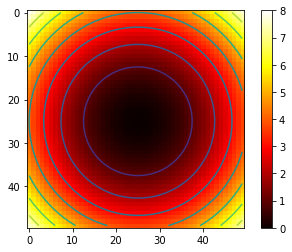

In [6]:
plt.imshow(values, cmap='hot');
plt.colorbar();
plt.contour(values);

In [17]:
np.mgrid[-2:2:50j, -2:2:50j].shape

(2, 50, 50)

In [20]:
values.shape

(50, 50)

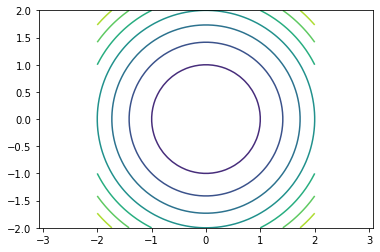

In [15]:
x, y = np.mgrid[-2:2:50j, -2:2:50j]
values = f(x, y)
plt.contour(x, y, values);
plt.axis('equal');

In [22]:
x, y, z = np.mgrid[-2:2:50j, -2:2:25j, 0:1:10j]

In [23]:
u, v = 1.0, 1.0
x = np.linspace(-1, 1, 100)

In [24]:
np.linspace(-2, 2, 5)

array([-2., -1.,  0.,  1.,  2.])

In [30]:
np.arange(-1, 1, 0.4)

array([-1. , -0.6, -0.2,  0.2,  0.6])

In [26]:
x, y = np.mgrid[-2:2:50j, -2:2:50j]

In [27]:
x.shape, y.shape

((50, 50), (50, 50))

In [28]:
np.mgrid[-1:1:5j, -1:1:3j]

array([[[-1. , -1. , -1. ],
        [-0.5, -0.5, -0.5],
        [ 0. ,  0. ,  0. ],
        [ 0.5,  0.5,  0.5],
        [ 1. ,  1. ,  1. ]],

       [[-1. ,  0. ,  1. ],
        [-1. ,  0. ,  1. ],
        [-1. ,  0. ,  1. ],
        [-1. ,  0. ,  1. ],
        [-1. ,  0. ,  1. ]]])

In [31]:
u = np.ones_like(x)

In [40]:
u.shape

(10, 10)

In [36]:
u

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [37]:
v = np.ones_like(x)

In [39]:
x, y = np.mgrid[-2:2:10j, -2:2:10j]
u = np.ones_like(x)
v = np.ones_like(x)

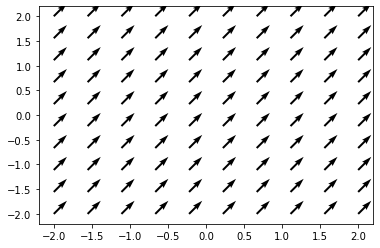

In [35]:
# Look at the documentation of plt.quiver to see more.
plt.clf()
plt.quiver(x, y, u, v);

## Streamlines/Path lines

- Integrate the trajectory of a "particle" starting at some initial condition, ic, for a given amount of time.

$$ \frac{dx}{dt} = u$$

$$ \frac{dy}{dt} = v$$

We are given an initial condition, $ic = (x_0, y_0)$ and integrate it for different times.

Note that once we can do path lines, we can just freeze the velocity at a given time and compute the pathlines to plot them as "streamlines".

In [41]:
ic = np.array([-2, -2])
times = np.linspace(0, 5, 10)

In [45]:
times

array([0.        , 0.55555556, 1.11111111, 1.66666667, 2.22222222,
       2.77777778, 3.33333333, 3.88888889, 4.44444444, 5.        ])

In [46]:
times[99]

IndexError: index 99 is out of bounds for axis 0 with size 10

In [47]:
odeint?

In [48]:
def vel(r, t):
    # Here we receive two arugments r - position of the particle.
    # t is the time.
    #x, y = r
    return np.array([1.0, 1.0])

In [49]:
sol = odeint(vel, ic, times)

In [50]:
sol.shape

(10, 2)

In [51]:
sx, sy = sol.T

Now plot the solution to show the path lines.

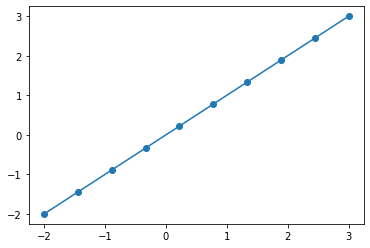

In [52]:
plt.plot(sx, sy, '-o')

For a collection of points we repeat the process in a loop.

(-2.2, 2.2, -3.274338408475892, 2.77464626797677)

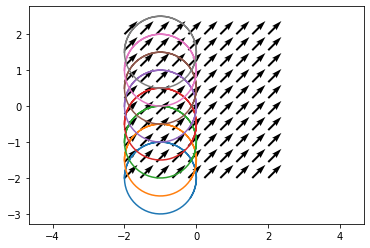

In [62]:
plt.quiver(x, y, u, v)
for i in range(8):
    ic = np.array([-2, -2 + i*0.5])
    sol = odeint(vel, ic, times)
    sx, sy = sol.T
    plt.plot(sx, sy)
plt.axis('equal')

Let us solve a slightly different problem now.

$(u, v) = (A \sin(\omega t), B \cos (\omega t))$

Let us first pick $A, B, \omega = 1, 1, 1$

We will pick the I.C. to be at the origin.

In [54]:
def vel(r, t):
    omega = 1
    a, b = 1, 1
    return np.array([a*np.sin(omega*t), b*np.cos(omega*t)])

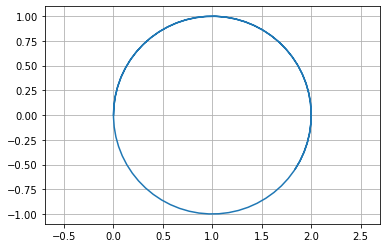

In [55]:
ic = np.array([0.0, 0.0])
times = np.linspace(0, 10, 100)
px, py = odeint(vel, ic, times).T
plt.plot(px, py)
plt.grid()
plt.axis('equal');

## Plotting streaklines

To do this, we start new particles at different times.  Let us release particles every dt time steps from the point (0, 0) and do so for a total time of $T=n dt$ seconds.

So the first point is integrated to from 0 to T seconds, the second to from dt to T, third from 2*dt to T etc.

So for each particle we must integrate from t=i*dt to T and only plot the final value.

The result will have two values, one at t=0 and one at t=T so we store/plot the last value.

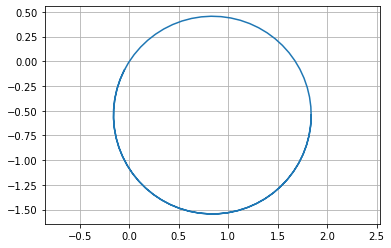

In [56]:
ic = np.array([0.0, 0.0])
dt = 0.1
n = 100
T = n*dt
sx, sy = [], []
for i in range(n):
    start = i*dt
    res = odeint(vel, ic, [start, T])
    sx.append(res[1,0])
    sy.append(res[1,1])
plt.plot(sx, sy)
plt.grid()
plt.axis('equal');

Showing both pathlines and streaklines

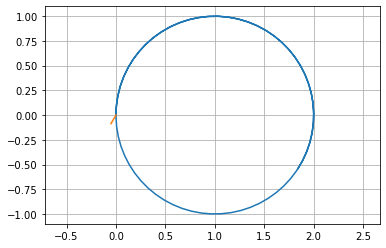

In [58]:
plt.plot(px, py)
plt.plot(res[:,0], res[:,1],)
plt.grid()
plt.axis('equal');